# 🕵️‍♂️ Fase 3: Detección de Anomalías (Autoencoder)

El modelo XGBoost del notebook anterior es excelente para detectar fallas que **ya conocemos**. Pero, ¿qué pasa si la máquina se rompe de una forma que nunca antes vimos?

Para eso usaremos un **Autoencoder** en PyTorch. Este modelo se entrena **solo con datos normales** (funcionamiento sano). Aprende a reconstruir las señales. Cuando llega un dato anómalo, no sabe cómo reconstruirlo bien, y el **Error de Reconstrucción** se dispara, alertándonos de la anomalía.

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

plt.style.use('dark_background')
device = torch.device('cpu')
print(f"Usando dispositivo: {device}")

Usando dispositivo: cpu


## 1. Preparación de los Datos

In [2]:
df = pd.read_csv('../data/ai4i2020_fe.csv')

features = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 
            'Torque [Nm]', 'Tool wear [min]', 'delta_temp', 'power_kw', 'wear_torque']

# IMPORTANTE: Separar datos normales de los anómalos
df_normal = df[df['Machine failure'] == 0]
df_anomaly = df[df['Machine failure'] == 1]

# Entrenaremos el scaler SOLO con datos normales
scaler = StandardScaler()
X_normal = scaler.fit_transform(df_normal[features])
X_anomaly = scaler.transform(df_anomaly[features])

X_train, X_val = train_test_split(X_normal, test_size=0.1, random_state=42)

train_tensor = torch.FloatTensor(X_train).to(device)
val_tensor = torch.FloatTensor(X_val).to(device)
anomaly_tensor = torch.FloatTensor(X_anomaly).to(device)

train_loader = DataLoader(TensorDataset(train_tensor, train_tensor), batch_size=64, shuffle=True)

## 2. Arquitectura del Autoencoder

In [3]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super(Autoencoder, self).__init__()
        # Encoder: Comprime la información
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(True),
            nn.Linear(16, 8),
            nn.ReLU(True),
            nn.Linear(8, 4)  # Espacio latente comprimido
        )
        # Decoder: Intenta reconstruir
        self.decoder = nn.Sequential(
            nn.Linear(4, 8),
            nn.ReLU(True),
            nn.Linear(8, 16),
            nn.ReLU(True),
            nn.Linear(16, input_dim)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

model = Autoencoder(input_dim=len(features)).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

## 3. Entrenamiento

In [4]:
epochs = 50
train_losses = []

for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for batch_x, _ in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_x)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    train_losses.append(epoch_loss / len(train_loader))
    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {train_losses[-1]:.4f}')

plt.plot(train_losses, color='#2ecc71')
plt.title('Curva de Entrenamiento del Autoencoder')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.show()

Epoch [10/50], Loss: 0.1111
Epoch [20/50], Loss: 0.0185
Epoch [30/50], Loss: 0.0174
Epoch [40/50], Loss: 0.0168
Epoch [50/50], Loss: 0.0166


<Figure size 640x480 with 1 Axes>

## 4. Estableciendo el Umbral de Anomalía

Umbral de Anomalía establecido en: 0.1124


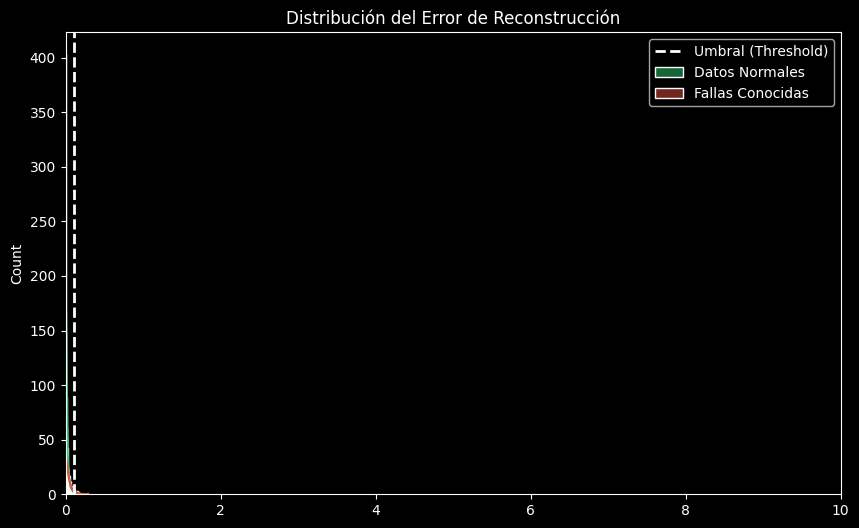

In [5]:
model.eval()
with torch.no_grad():
    # Evaluamos en los datos de validación NORMALES
    val_preds = model(val_tensor)
    val_loss = torch.mean((val_preds - val_tensor)**2, dim=1).cpu().numpy()
    
    # Evaluamos en los datos ANÓMALOS conocidos
    anomaly_preds = model(anomaly_tensor)
    anomaly_loss = torch.mean((anomaly_preds - anomaly_tensor)**2, dim=1).cpu().numpy()

# El umbral será el percentil 99 del error de los datos normales
threshold = np.percentile(val_loss, 99)
print(f"Umbral de Anomalía establecido en: {threshold:.4f}")

plt.figure(figsize=(10, 6))
sns.histplot(val_loss, bins=50, color='#2ecc71', label='Datos Normales', kde=True)
sns.histplot(anomaly_loss, bins=50, color='#e74c3c', label='Fallas Conocidas', kde=True)
plt.axvline(threshold, color='white', linestyle='dashed', linewidth=2, label='Umbral (Threshold)')
plt.xlim(0, 10)
plt.title('Distribución del Error de Reconstrucción')
plt.legend()
plt.show()

In [6]:
torch.save(model.state_dict(), '../models/autoencoder.pt')
joblib.dump(scaler, '../models/scalers/autoencoder_scaler.pkl')
# Guardamos el umbral para usarlo en la API
with open('../models/anomaly_threshold.txt', 'w') as f:
    f.write(str(threshold))
print("Modelos, scalers y umbral guardados exitosamente.")

Modelos, scalers y umbral guardados exitosamente.
